# Breast Cancer Wisconsin: Classificazione

Progetto per l'esame di *Apprendimento Automatico e Apprendimento Profondo*, A.A. 2025/2026.

Dataset: **Breast Cancer Wisconsin (Diagnostic)** dal repository UCI (id 17).
Obiettivo: classificare le masse mammarie come maligne (M) o benigne (B) a
partire da 30 feature numeriche estratte da immagini di agoaspirato.

Studente: Stefano Valloncini, matricola 0322500114

In [1]:
import os
os.environ["PYTHONHASHSEED"] = "42"
os.environ["TF_DETERMINISTIC_OPS"] = "1"

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve,
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

SEED = 42
np.random.seed(SEED)
keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()

IMG_DIR = Path("docs/images")
IMG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")


2026-05-12 17:31:11.419029: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Caricamento del dataset

Il dataset Wisconsin Diagnostic è stato raccolto da Wolberg, Street e Mangasarian
a partire da immagini digitalizzate di agoaspirato di masse mammarie. Ogni record
contiene 30 misure (media, errore standard e valore peggiore di dieci
caratteristiche morfologiche dei nuclei cellulari come raggio, texture, perimetro,
area, ecc.) e un'etichetta diagnostica.

In [2]:
data = fetch_ucirepo(id=17)
X = data.data.features.copy()
y_raw = data.data.targets.squeeze()

# Le colonne UCI sono radius1/2/3, texture1/2/3, ecc.: il suffisso 1/2/3
# corrisponde a mean/se/worst. Le rinomino per leggerle senza fatica nei plot.
SUFFIX = {"1": "mean", "2": "se", "3": "worst"}
X.columns = [f"{c[:-1]}_{SUFFIX[c[-1]]}" for c in X.columns]

print(f"Numero di campioni: {len(X)}")
print(f"Numero di feature : {X.shape[1]}")
print("Distribuzione delle classi:")
print(y_raw.value_counts())


Numero di campioni: 569
Numero di feature : 30
Distribuzione delle classi:
Diagnosis
B    357
M    212
Name: count, dtype: int64


In [3]:
X.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Analisi esplorativa

Prima di addestrare i modelli vale la pena guardare come si distribuiscono le
classi e quali feature sono fortemente correlate fra loro.

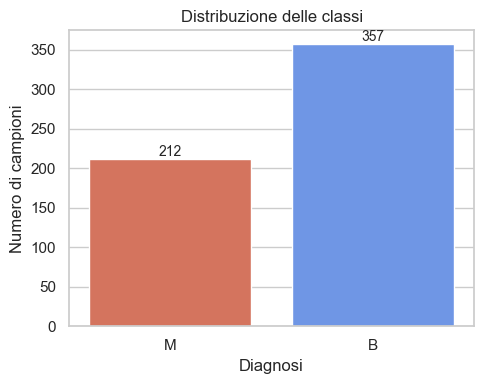

In [4]:
y = (y_raw == "M").astype(int)

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(x=y_raw, ax=ax, palette={"B": "#5B8FF9", "M": "#E8684A"})
ax.set_xlabel("Diagnosi")
ax.set_ylabel("Numero di campioni")
ax.set_title("Distribuzione delle classi")
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.savefig(IMG_DIR / "class_distribution.png", dpi=150)
plt.show()

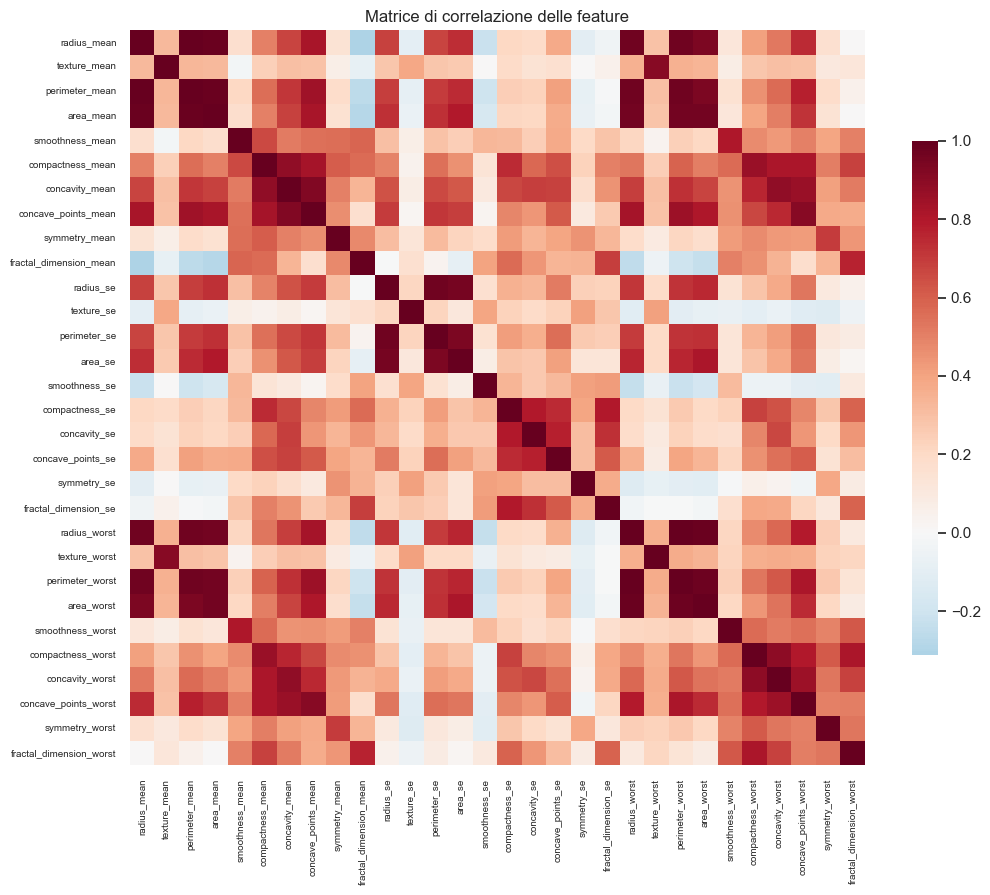

Valori mancanti per colonna: 0


In [5]:
# Le 30 feature sono organizzate in tre blocchi (mean, error, worst): le
# correlazioni piu' forti si trovano fra blocchi diversi sulla stessa quantita'
# (radius_mean vs radius_worst, ecc.).
fig, ax = plt.subplots(figsize=(11, 9))
corr = X.corr()
sns.heatmap(corr, cmap="RdBu_r", center=0, square=True,
            cbar_kws={"shrink": 0.7}, ax=ax, xticklabels=True, yticklabels=True)
ax.set_title("Matrice di correlazione delle feature")
plt.xticks(rotation=90, fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.savefig(IMG_DIR / "correlation_heatmap.png", dpi=150)
plt.show()

print("Valori mancanti per colonna:", X.isnull().sum().sum())

## Suddivisione dei dati e standardizzazione

Adotto uno split stratificato 60/20/20 in training, validation e test. Lo stesso
split viene utilizzato sia per gli algoritmi shallow sia per la rete MLP, come
richiesto dalla consegna. Lo standard scaling viene fittato solo sul training,
così da evitare leakage dal validation e dal test.

In [6]:
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.5, stratify=y_tmp, random_state=SEED
)

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

print(f"Train: {X_train_s.shape}, positivi: {y_train.sum()}/{len(y_train)}")
print(f"Val  : {X_val_s.shape}, positivi: {y_val.sum()}/{len(y_val)}")
print(f"Test : {X_test_s.shape}, positivi: {y_test.sum()}/{len(y_test)}")

Train: (341, 30), positivi: 127/341
Val  : (114, 30), positivi: 43/114
Test : (114, 30), positivi: 42/114


## Analisi PCA

Riduco la dimensionalità a fini esplorativi per capire quanta varianza è
catturata dalle prime componenti e per visualizzare la separabilità sul piano
delle prime due componenti principali.

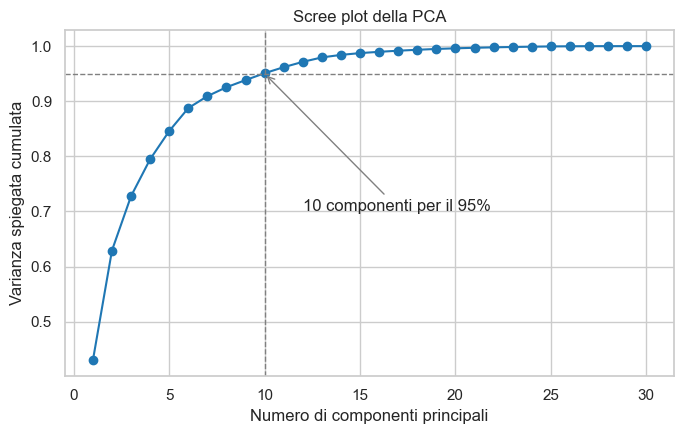

Componenti necessarie per >=95% varianza: 10


In [7]:
pca_full = PCA(random_state=SEED).fit(X_train_s)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
k95 = int(np.searchsorted(cum_var, 0.95)) + 1

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(range(1, len(cum_var) + 1), cum_var, marker="o", color="#1f77b4")
ax.axhline(0.95, ls="--", color="gray", lw=1)
ax.axvline(k95, ls="--", color="gray", lw=1)
ax.set_xlabel("Numero di componenti principali")
ax.set_ylabel("Varianza spiegata cumulata")
ax.set_title("Scree plot della PCA")
ax.annotate(f"{k95} componenti per il 95%", xy=(k95, 0.95),
            xytext=(k95 + 2, 0.7),
            arrowprops=dict(arrowstyle="->", color="gray"))
plt.tight_layout()
plt.savefig(IMG_DIR / "pca_variance.png", dpi=150)
plt.show()

print(f"Componenti necessarie per >=95% varianza: {k95}")

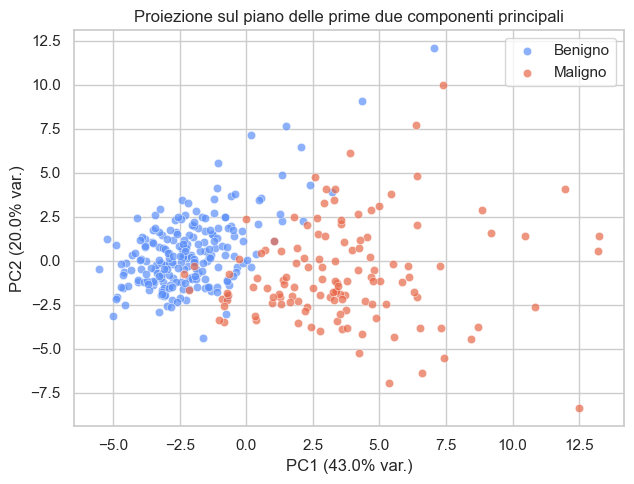

In [8]:
pca2 = PCA(n_components=2, random_state=SEED).fit(X_train_s)
Z_train = pca2.transform(X_train_s)

fig, ax = plt.subplots(figsize=(6.5, 5))
for label, color, name in [(0, "#5B8FF9", "Benigno"), (1, "#E8684A", "Maligno")]:
    mask = y_train.values == label
    ax.scatter(Z_train[mask, 0], Z_train[mask, 1], c=color, label=name,
               alpha=0.7, edgecolor="white", linewidth=0.4)
ax.set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% var.)")
ax.set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% var.)")
ax.set_title("Proiezione sul piano delle prime due componenti principali")
ax.legend()
plt.tight_layout()
plt.savefig(IMG_DIR / "pca_2d_scatter.png", dpi=150)
plt.show()

## Algoritmi shallow

Per ognuno dei quattro modelli faccio un piccolo grid search con 5-fold
cross-validation interna al training set, ottimizzando l'AUC. Il modello finale
viene poi rifittato su training+validation e valutato sul test set una sola
volta; il validation set serve in maniera esplicita più avanti per la
early-stopping del MLP.

In [9]:
def evaluate(model, X_te, y_te, name):
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_te)[:, 1]
    else:
        proba = model.decision_function(X_te)
    pred = (proba >= 0.5).astype(int)
    return {
        "model": name,
        "accuracy":  accuracy_score(y_te, pred),
        "precision": precision_score(y_te, pred),
        "recall":    recall_score(y_te, pred),
        "f1":        f1_score(y_te, pred),
        "roc_auc":   roc_auc_score(y_te, proba),
        "proba":     proba,
        "pred":      pred,
    }

X_trainval_s = np.vstack([X_train_s, X_val_s])
y_trainval = pd.concat([y_train, y_val]).reset_index(drop=True)

results = {}
grids = {}

In [10]:
grid_lr = GridSearchCV(
    LogisticRegression(max_iter=5000, solver="liblinear", random_state=SEED),
    param_grid={"C": [0.01, 0.1, 1, 10], "penalty": ["l2"]},
    cv=5, scoring="roc_auc", n_jobs=-1,
)
grid_lr.fit(X_train_s, y_train)
best_lr = grid_lr.best_estimator_.fit(X_trainval_s, y_trainval)
grids["LogisticRegression"] = grid_lr.best_params_
results["LogisticRegression"] = evaluate(best_lr, X_test_s, y_test, "LogisticRegression")
print("Best params:", grid_lr.best_params_)

Best params: {'C': 10, 'penalty': 'l2'}


In [11]:
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=SEED, n_jobs=-1),
    param_grid={"n_estimators": [100, 200], "max_depth": [None, 5, 10]},
    cv=5, scoring="roc_auc", n_jobs=-1,
)
grid_rf.fit(X_train_s, y_train)
best_rf = grid_rf.best_estimator_.fit(X_trainval_s, y_trainval)
grids["RandomForest"] = grid_rf.best_params_
results["RandomForest"] = evaluate(best_rf, X_test_s, y_test, "RandomForest")
print("Best params:", grid_rf.best_params_)

Best params: {'max_depth': 5, 'n_estimators': 100}


In [12]:
# probability=True abilita predict_proba via Platt scaling, indispensabile per ROC AUC.
grid_svm = GridSearchCV(
    SVC(kernel="rbf", probability=True, random_state=SEED),
    param_grid={"C": [0.1, 1, 10], "gamma": ["scale", 0.01, 0.1]},
    cv=5, scoring="roc_auc", n_jobs=-1,
)
grid_svm.fit(X_train_s, y_train)
best_svm = grid_svm.best_estimator_.fit(X_trainval_s, y_trainval)
grids["SVM_RBF"] = grid_svm.best_params_
results["SVM_RBF"] = evaluate(best_svm, X_test_s, y_test, "SVM_RBF")
print("Best params:", grid_svm.best_params_)

Best params: {'C': 10, 'gamma': 0.01}


In [13]:
grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid={"n_neighbors": [3, 5, 7, 11], "weights": ["uniform", "distance"]},
    cv=5, scoring="roc_auc", n_jobs=-1,
)
grid_knn.fit(X_train_s, y_train)
best_knn = grid_knn.best_estimator_.fit(X_trainval_s, y_trainval)
grids["KNN"] = grid_knn.best_params_
results["KNN"] = evaluate(best_knn, X_test_s, y_test, "KNN")
print("Best params:", grid_knn.best_params_)

Best params: {'n_neighbors': 11, 'weights': 'distance'}


## Rete neurale (MLP)

Per la parte di deep learning ho costruito un percettrone multilivello con due
hidden layer (64 e 32 unità, attivazione ReLU) intervallati da dropout per
contenere l'overfitting. La output layer è un singolo neurone con sigmoide, in
linea con il problema binario.

Il training sfrutta il validation set per l'early stopping: questo è anche il
motivo per cui in tutto il progetto si è tenuto un validation separato pur
facendo cross-validation per gli shallow.

In [14]:
def build_mlp(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(32, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy", keras.metrics.AUC(name="auc")],
    )
    return model

mlp = build_mlp(X_train_s.shape[1])
mlp.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
early = callbacks.EarlyStopping(
    monitor="val_loss", patience=10, restore_best_weights=True
)

history = mlp.fit(
    X_train_s, y_train.values,
    validation_data=(X_val_s, y_val.values),
    epochs=100, batch_size=32,
    callbacks=[early], verbose=0,
)

print(f"Training fermato dopo {len(history.history['loss'])} epoche")

Training fermato dopo 38 epoche


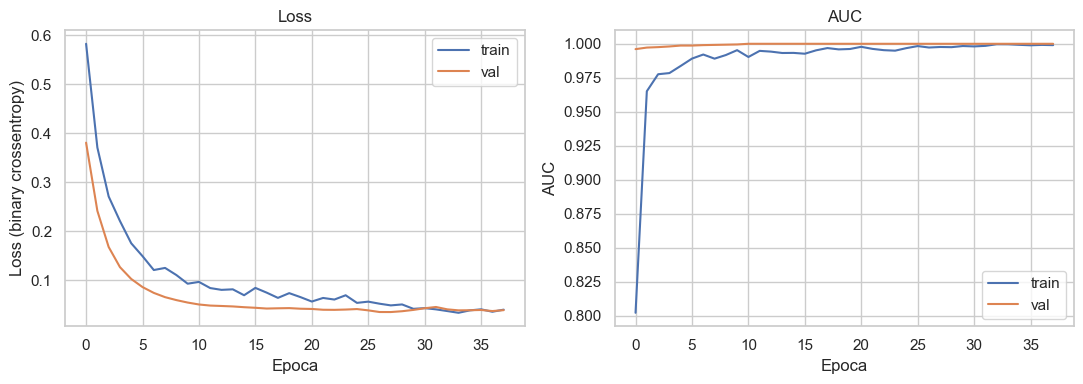

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="val")
axes[0].set_xlabel("Epoca")
axes[0].set_ylabel("Loss (binary crossentropy)")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history.history["auc"], label="train")
axes[1].plot(history.history["val_auc"], label="val")
axes[1].set_xlabel("Epoca")
axes[1].set_ylabel("AUC")
axes[1].set_title("AUC")
axes[1].legend()

plt.tight_layout()
plt.savefig(IMG_DIR / "mlp_training_history.png", dpi=150)
plt.show()

In [17]:
class KerasProbaWrap:
    """Adattatore minimo per riutilizzare la funzione evaluate() sulla MLP."""
    def __init__(self, model):
        self.model = model
    def predict_proba(self, X):
        p = self.model.predict(X, verbose=0).ravel()
        return np.column_stack([1 - p, p])

results["MLP"] = evaluate(KerasProbaWrap(mlp), X_test_s, y_test, "MLP")

## Metriche di valutazione

Calcolo accuracy, precision, recall, F1 e ROC AUC per tutti e cinque i modelli
sullo stesso test set. Il calcolo è già stato fatto dalla funzione `evaluate`;
qui aggrego i risultati in una tabella e produco il bar chart riassuntivo.

In [18]:
metrics_df = pd.DataFrame(
    [{k: v for k, v in r.items() if k in ("model", "accuracy", "precision", "recall", "f1", "roc_auc")}
     for r in results.values()]
).set_index("model").round(4)

metrics_df

,accuracy,precision,recall,f1,roc_auc
model,,,,,
LogisticRegression,0.9737,0.9756,0.9524,0.9639,0.9848
RandomForest,0.9737,0.9756,0.9524,0.9639,0.9964
SVM_RBF,0.9825,1.0000,0.9524,0.9756,0.9947
KNN,0.9737,0.9756,0.9524,0.9639,0.9934
MLP,0.9825,1.0000,0.9524,0.9756,0.9947


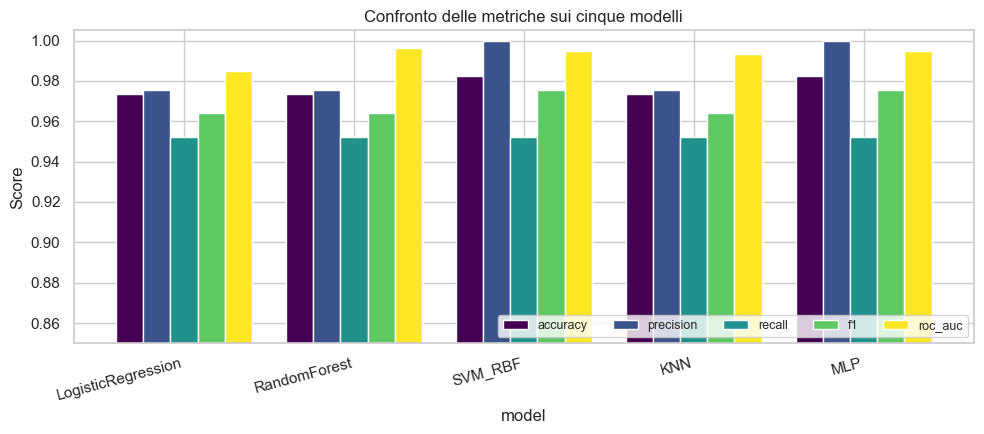

In [19]:
fig, ax = plt.subplots(figsize=(10, 4.5))
metrics_df.plot(kind="bar", ax=ax, colormap="viridis", width=0.8)
ax.set_ylim(0.85, 1.005)
ax.set_ylabel("Score")
ax.set_title("Confronto delle metriche sui cinque modelli")
ax.legend(loc="lower right", ncol=5, fontsize=9)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig(IMG_DIR / "metrics_comparison.png", dpi=150)
plt.show()

## Matrici di confusione

Una matrice di confusione per ciascun modello. La classe positiva è M (maligno);
i falsi negativi sul tumore maligno sono l'errore clinicamente più rilevante.

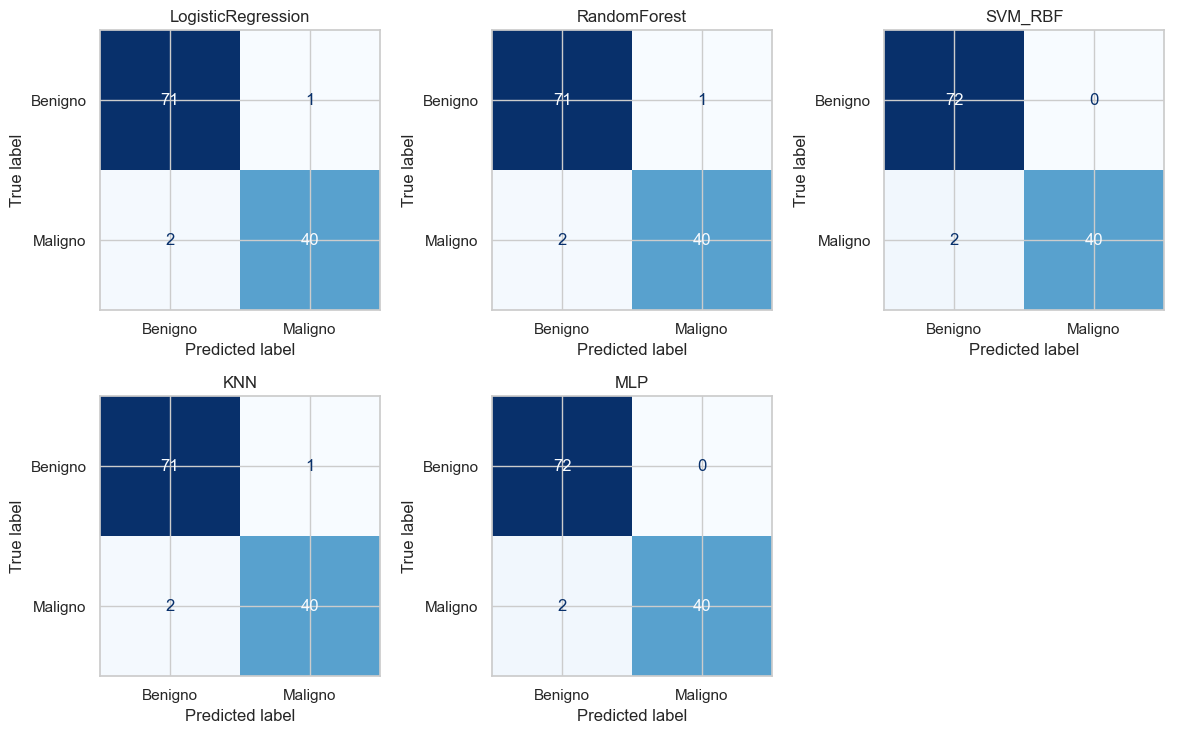

In [20]:
name_to_file = {
    "LogisticRegression": "confusion_matrix_logreg.png",
    "RandomForest":       "confusion_matrix_rf.png",
    "SVM_RBF":            "confusion_matrix_svm.png",
    "KNN":                "confusion_matrix_knn.png",
    "MLP":                "confusion_matrix_mlp.png",
}

fig, axes = plt.subplots(2, 3, figsize=(12, 7.5))
axes = axes.ravel()

for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, r["pred"])
    disp = ConfusionMatrixDisplay(cm, display_labels=["Benigno", "Maligno"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name)
    fig.savefig(IMG_DIR / name_to_file[name], dpi=150, bbox_inches="tight")

axes[-1].axis("off")
plt.tight_layout()
plt.show()

# Salvataggio dei singoli plot in file separati per essere inclusi nella relazione.
for name, r in results.items():
    cm = confusion_matrix(y_test, r["pred"])
    fig_s, ax_s = plt.subplots(figsize=(4, 3.5))
    ConfusionMatrixDisplay(cm, display_labels=["Benigno", "Maligno"]).plot(
        ax=ax_s, cmap="Blues", colorbar=False
    )
    ax_s.set_title(name)
    plt.tight_layout()
    fig_s.savefig(IMG_DIR / name_to_file[name], dpi=150)
    plt.close(fig_s)

## Curve ROC

Le curve ROC dei cinque modelli sovrapposte, con AUC riportata in legenda. La
diagonale di riferimento corrisponde a un classificatore casuale (AUC = 0.5).

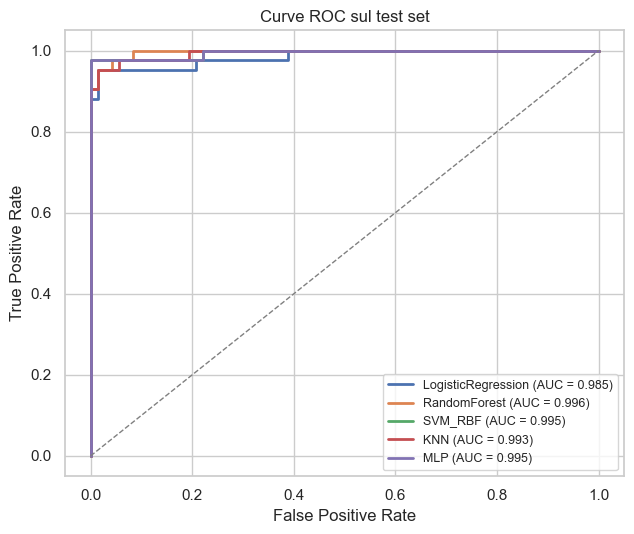

In [21]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_test, r["proba"])
    ax.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {r['roc_auc']:.3f})")
ax.plot([0, 1], [0, 1], ls="--", color="gray", lw=1)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Curve ROC sul test set")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig(IMG_DIR / "roc_curves_all.png", dpi=150)
plt.show()

## Conclusioni

I quattro algoritmi shallow ottengono tutti AUC molto elevata sul test set.
Il motivo si vede già nella PCA: nello spazio standardizzato le due classi
sono quasi linearmente separabili, e con 569 campioni qualunque modello ben
tarato si avvicina al tetto. Con il determinismo abilitato la MLP finisce
esattamente sullo stesso punto operativo di SVM (accuracy 0.9825, F1 0.9756,
AUC 0.9947) - capacità extra che resta poco sfruttabile su una scala di
dati così piccola.

In un contesto clinico la metrica che peserebbe di più sarebbe la recall
sulla classe maligna: un falso negativo significa mancare una diagnosi di
tumore. Sul nostro test set tutti i modelli mantengono recall a 0.9524.

Tra i limiti: nessuna nested CV per separare la selezione degli iperparametri
dalla stima dell'errore, e nessun test di significatività fra i modelli.
Un'estensione naturale sarebbe SHAP per vedere quali feature pesano di più
nelle predizioni del modello migliore.